# scPipe-Multimodal Seurat

In [1]:
# if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
# BiocManager::install(c("harmony"))
# BiocManager::install(c("glmGamPoi"))
# BiocManager::install('limma')

# install.packages("Seurat")
# install.packages("sctransform")

# install.packages('devtools')
# devtools::install_github('immunogenomics/presto')

In [35]:
# Library import

library(Seurat)
library(ggplot2)
library(sctransform)
library(harmony)
library(patchwork)
library(dplyr)
library(magrittr)

set.seed(1)

# Multicore CPU usage activation - Future

library(future)

# plan("multicore", workers = 24) # Mac Pro 6.1
# plan(workers = 36) # iMac Pro 1.1
# plan("multicore", workers = 8) # 4 core Intel CPU and M1 have 8 threads
# plan("multicore", workers = 12) # 6 core Intel CPU has 12 threads
plan("multicore", workers = 10) # 10 core M1 Pro CPU has 10 threads

# Set RAM Size to 3/4 of total RAM

# options(future.globals.maxSize = 48000 * 1024^2) # Mac Pros have 64 Gb
options(future.globals.maxSize = 16000 * 1024^2) # iMacs and MacBook Pros have 16 Gb

future.seed=TRUE # Removes future-generated statistical errors

In [3]:
data_dir <- './3/filtered_feature_bc_matrix'
counts <- Read10X(data.dir = data_dir)
Chromium_3 = CreateSeuratObject(counts = counts)
Chromium_3[["percent.mt"]] <- PercentageFeatureSet(Chromium_3, pattern = "^MT-")

data_dir <- './5/filtered_feature_bc_matrix'
counts <- Read10X(data.dir = data_dir)
Chromium_5 = CreateSeuratObject(counts = counts)
Chromium_5[["percent.mt"]] <- PercentageFeatureSet(Chromium_5, pattern = "^MT-")

In [4]:
# Merge
merged_seurat <- merge(Chromium_3, y = Chromium_5, 
                       add.cell.ids = c("Capture_3'","Capture_5'"))

# Split by capture technology
merged_seurat[['Capture']] = as.character(sapply(
    rownames(merged_seurat@meta.data), function(x) {strsplit(x,"_")[[1]][[2]]}))
head(merged_seurat@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,Capture
,<chr>,<dbl>,<int>,<dbl>,<chr>
Capture_3'_AAACCCAAGTGAACAT-1,SeuratProject,1778,156,90.213723,3'
Capture_3'_AAACCCACACAACGAG-1,SeuratProject,16951,4423,28.169430,3'
Capture_3'_AAACCCAGTGGAACCA-1,SeuratProject,4490,1793,6.035635,3'
Capture_3'_AAACGAAAGTACCCTA-1,SeuratProject,3926,195,94.243505,3'
Capture_3'_AAACGAACAAGCCTGC-1,SeuratProject,2932,1428,8.424284,3'
Capture_3'_AAACGCTCATATAGCC-1,SeuratProject,19092,5242,11.842657,3'


In [5]:
tail(merged_seurat@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,Capture
,<chr>,<dbl>,<int>,<dbl>,<chr>
Capture_5'_TTTGTCAGTAAGAGGA-4,SeuratProject,2806,1072,4.989309,5'
Capture_5'_TTTGTCAGTATAGGGC-4,SeuratProject,3099,105,94.127138,5'
Capture_5'_TTTGTCAGTCAAAGCG-4,SeuratProject,26114,4613,16.171402,5'
Capture_5'_TTTGTCAGTCCTAGCG-4,SeuratProject,3348,59,95.997611,5'
Capture_5'_TTTGTCATCAACGAAA-4,SeuratProject,15769,4162,10.609424,5'
Capture_5'_TTTGTCATCATCGCTC-4,SeuratProject,81435,9600,7.630626,5'


In [6]:
merged_seurat

An object of class Seurat 
36601 features across 35357 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts.1, counts.2

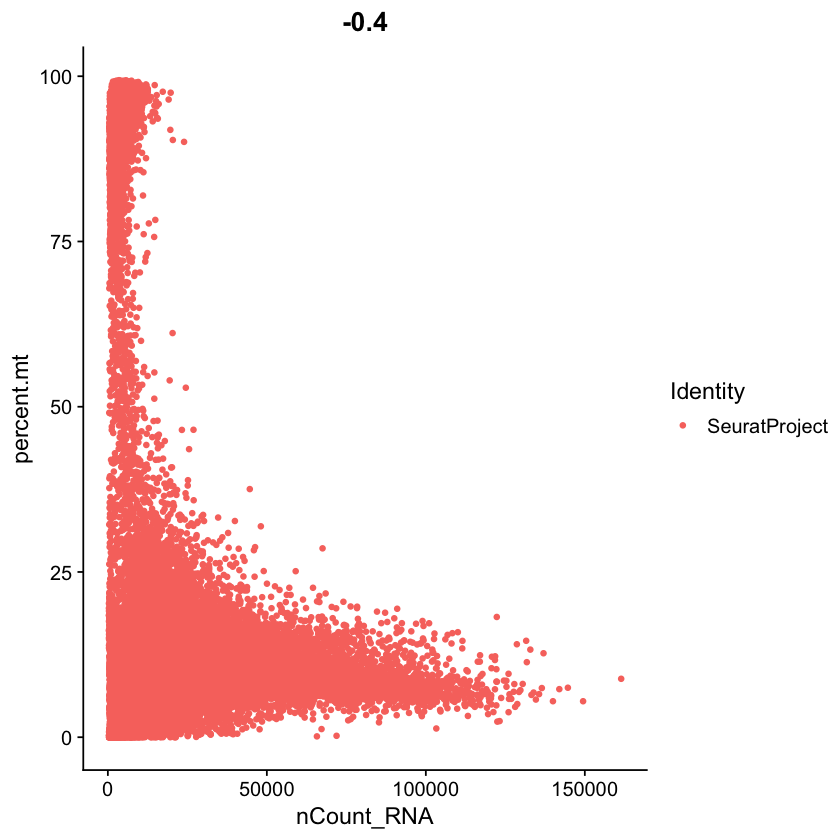

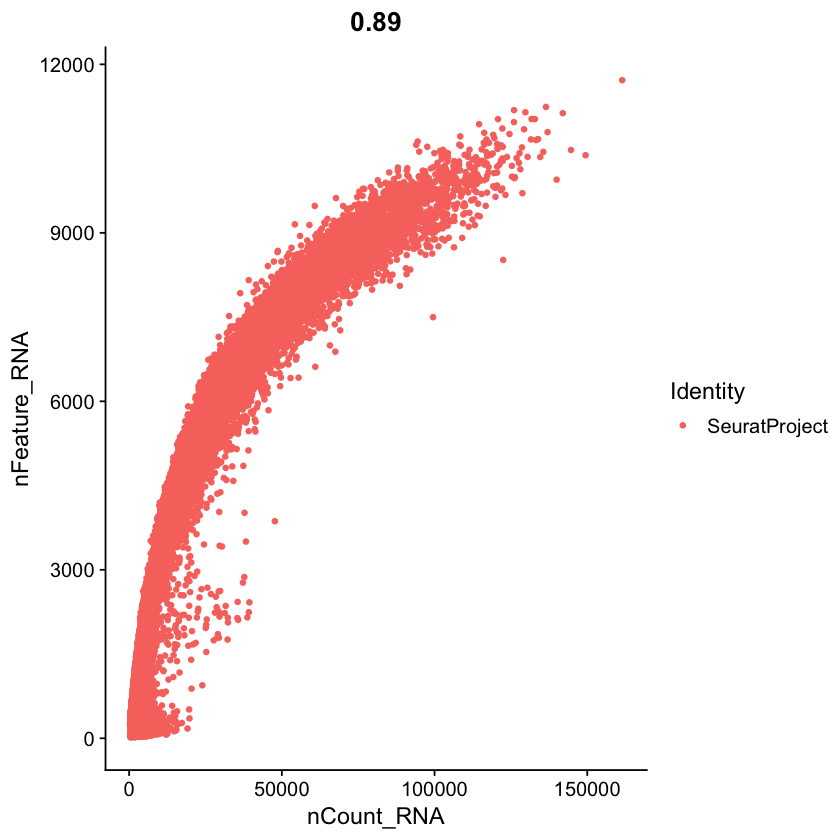

In [7]:
# FeatureScatter Plot QC

plot_QC_1 <- FeatureScatter(merged_seurat, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot_QC_2 <- FeatureScatter(merged_seurat, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot_QC_1
plot_QC_2

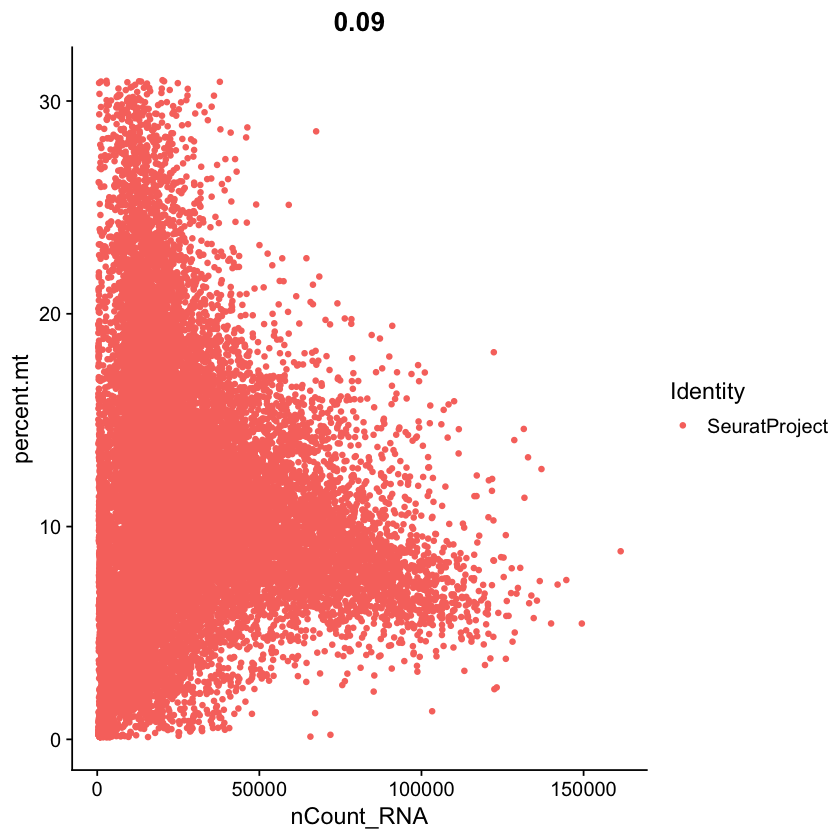

An object of class Seurat 
36601 features across 25962 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts.1, counts.2

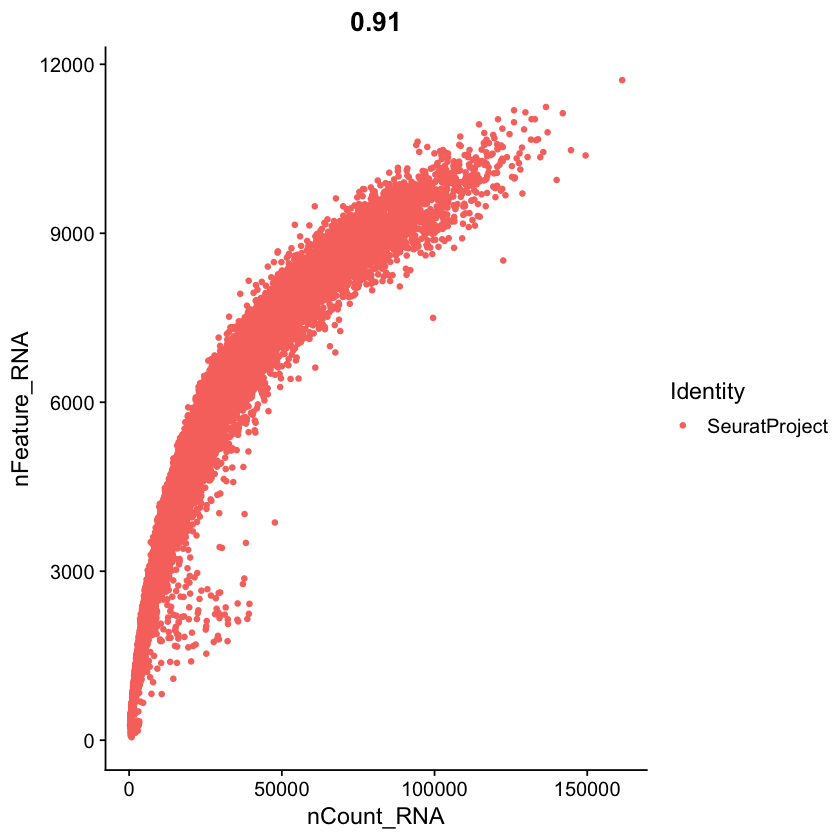

In [8]:
merged_seurat_QC <- subset(merged_seurat, subset = 
                           nFeature_RNA > 0 
                           & nFeature_RNA < 12000
                           & percent.mt < 31
                           & percent.mt > 0.1
                          )
plot_QC_1 <- FeatureScatter(merged_seurat_QC, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot_QC_2 <- FeatureScatter(merged_seurat_QC, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot_QC_1
plot_QC_2
merged_seurat_QC

In [9]:
merged_seurat <- merged_seurat_QC

In [10]:
# Normalize data
merged_seurat <- NormalizeData(merged_seurat, normalization.method = "LogNormalize", scale.factor = 10000)

merged_seurat <- FindVariableFeatures(merged_seurat, selection.method = "vst", nfeatures = 2000)

merged_seurat <- ScaleData(merged_seurat)

Normalizing layer: counts.1

Normalizing layer: counts.2

Finding variable features for layer counts.1

Finding variable features for layer counts.2

Centering and scaling data matrix



In [11]:
# Calculate PCs using variable features
merged_seurat <- RunPCA(merged_seurat, npcs = 40)

PC_ 1 
Positive:  PIP, PSCA, SCD, AGR2, S100A14, SLC39A6, PHLDA2, H2AFZ, WFDC2, TACSTD2 
	   PCLAF, CKS2, AC013652.1, UBE2T, SORCS1, NUDT8, ZWINT, PNMT, S100P, RRM2 
	   CKS1B, MKI67, GINS2, SPAG17, MZB1, CENPF, AC021148.2, BRIP1, ANLN, ARL6IP1 
Negative:  IGFBP7, TCF4, SPARC, SPARCL1, CALD1, CAVIN1, NNMT, A2M, HSPG2, COL4A2 
	   DLC1, RBMS3, SERPING1, FSTL1, COL4A1, SASH1, LDB2, IGFBP4, LHFPL6, GNG11 
	   ENG, FN1, MGP, EMP1, RAMP2, FBN1, LAMA4, IFITM3, LAMB1, VCAN 
PC_ 2 
Positive:  SLC39A6, AGR2, TM4SF1, S100A14, PHLDA2, PIP, SCD, MT2A, TACSTD2, STMN1 
	   ERG, PSCA, CKS1B, IGFBP5, H2AFZ, WFDC2, INSR, MT1X, NUDT8, PCLAF 
	   AC013652.1, UBE2T, ECT2, CLU, ZWINT, RRM2, ANLN, LTBP1, MECOM, MKI67 
Negative:  SRGN, CXCR4, PTPRC, LAPTM5, HLA-B, ARHGDIB, CD74, CD52, RGS1, S100A4 
	   CORO1A, HLA-DPA1, HLA-DPB1, SAMSN1, RGCC, HCST, FYB1, LSP1, HLA-DRB1, VIM 
	   FXYD5, ITGB2, ARHGAP15, HLA-DRA, IL7R, DUSP2, CD69, ALOX5AP, ANXA1, ARL4C 
PC_ 3 
Positive:  DCN, SERPINF1, LUM, COL1A2, FBLN1, LR

In [12]:
harmonized_seurat <- RunHarmony(merged_seurat, 
                                group.by.vars = c("Capture"),
                                reduction = "pca", assay.use = "RNA", plot_convergence = FALSE, 
                                project.dim = F, reduction.save = "mRNA_harmony")

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony converged after 4 iterations



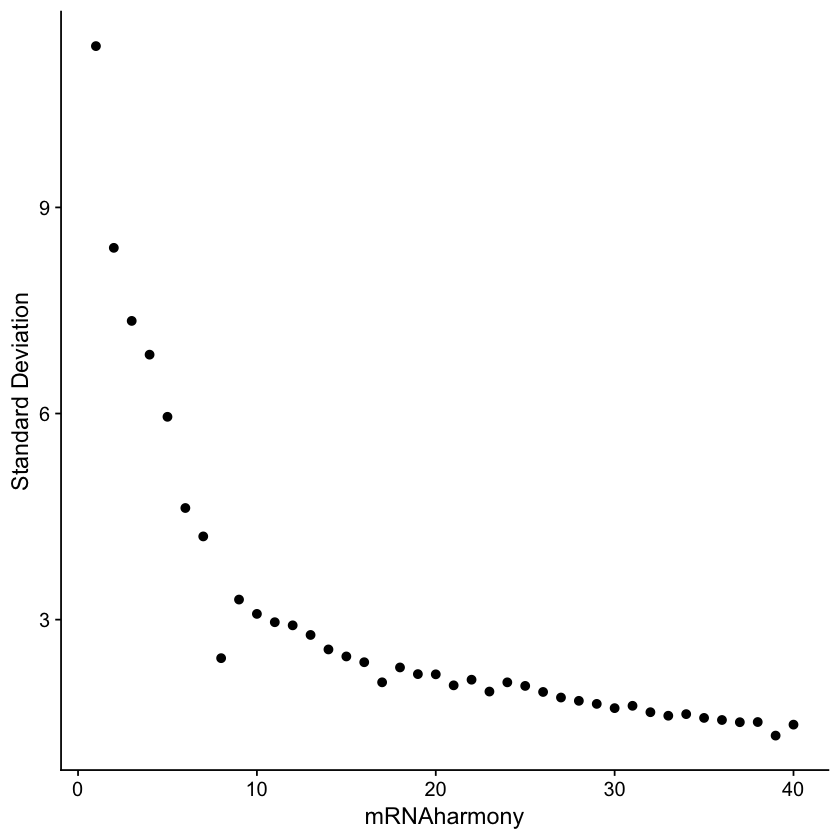

In [13]:
ElbowPlot(harmonized_seurat, ndims = 40, reduction = "mRNA_harmony")

In [14]:
harmonized_seurat <- RunUMAP(
  harmonized_seurat,
  reduction = "mRNA_harmony",
  dims = 1:30,
  reduction.name = "UMAP",  
  reduction.key = "UMAP_" 
)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
18:44:38 UMAP embedding parameters a = 0.9922 b = 1.112

18:44:38 Read 25962 rows and found 30 numeric columns

18:44:38 Using Annoy for neighbor search, n_neighbors = 30

18:44:38 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:44:39 Writing NN index file to temp file /var/folders/lk/54m90rgj1fqg895lxsgx1l180000gn/T//Rtmp1uM7L9/file8a9c1cf467d0

18:44:39 Searching Annoy index using 10 threads, search_k = 3000

18:44:40 Annoy recall = 100%

18:44:40 Commencing smooth kNN distance calib

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


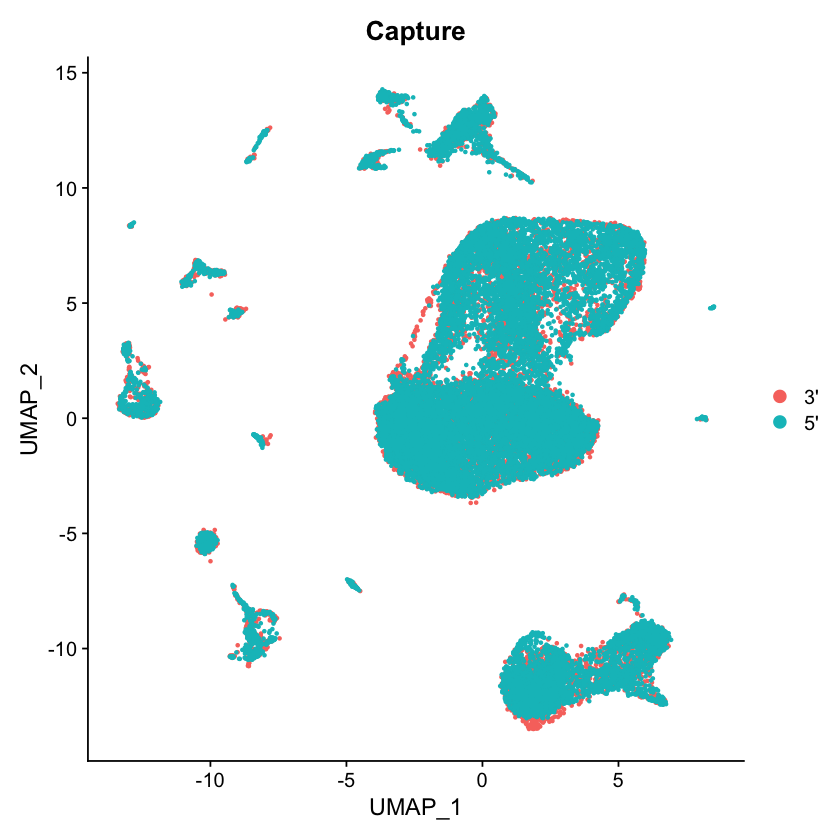

In [23]:
# Sample integration QC
DimPlot(harmonized_seurat, 
              reduction = "UMAP",
              group.by = "Capture",
              label=FALSE,
              pt.size = 0.5,
              label.size = 10)

ggsave("UMAP Harmony.jpeg", plot = last_plot(),
       width = 7, height = 6,     
       dpi = 1800,                
       type = "cairo")

In [56]:
harmonized_seurat <- FindNeighbors(
  harmonized_seurat, 
  reduction = "mRNA_harmony", 
  dims = 1:30 
)

Computing nearest neighbor graph

Computing SNN



In [36]:
harmonized_seurat <- readRDS("./Visium/Seurat_Clusters.rds")

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 25962
Number of edges: 968727

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9388
Number of communities: 15
Elapsed time: 4 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


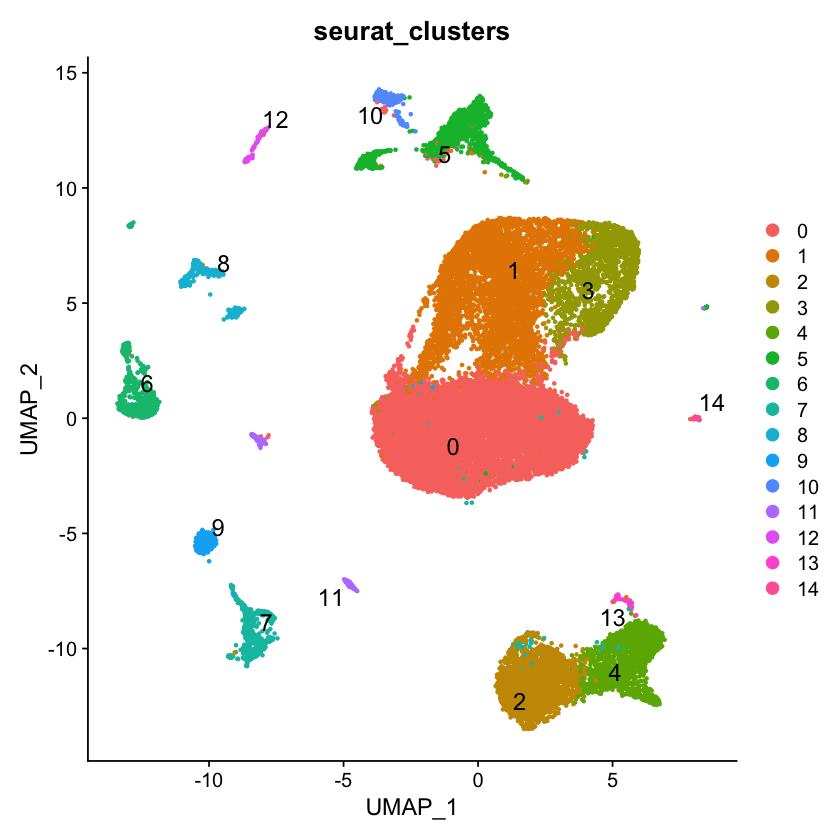

In [42]:
# Identify Clusters based on that graph
harmonized_seurat <- FindClusters(
  harmonized_seurat, 
  resolution = 0.22
)

# Seurat Clusters
DimPlot(harmonized_seurat, 
              reduction = "UMAP",
              group.by = "seurat_clusters",
              label = TRUE, pt.size = 0.5, 
              label.size = 5, repel = TRUE)

ggsave("scClusters.jpeg", plot = last_plot(),
       width = 7, height = 6,     
       dpi = 1800,                
       type = "cairo")

In [50]:
harmonized_seurat <- JoinLayers(harmonized_seurat)

In [5]:
DefaultAssay(harmonized_seurat) <- "RNA"

# Find markers
all_markers <- FindAllMarkers(
  harmonized_seurat,
  only.pos = TRUE,
  min.pct = 0.25,
  logfc.threshold = 1
)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14



In [6]:
# Save the table to a CSV file
write.csv(all_markers, "breast_cancer_cluster_markers.csv", row.names = FALSE)

In [43]:
new_names <- c(
  # TUMOR 
  "0"  = "Tumor",            # ERBB2+, GRB7+
  "1"  = "Dividing Tumor",   # EXO1+, RRM2+
  "3"  = "Dividing Tumor",   # CDC20+, CCNB1+
  "5"  = "Luminal A",            # TFF1++, AGR3++
  "10" = "Luminal B",            # PGR+, ESR1+

  # EPITHELIUM
  "12" = "Myoepithelial Cells",     # KRT14+, CALML3+
  "14" = "Ciliated Cells",          # FOXJ1+, CDC20B+, CFAP126+

  # STROMA
  "8"  = "Fibroblasts",             # DCN+, LUM+
  "6"  = "Endothelial Cells",       # CLDN5+, VWF+

  # IMMUNE 
  "2"  = "CD4 T-Cells",            # IL7R+, TCF7+
  "4"  = "CD8 T-Cells",            # CD8A+, GZMB+
  "13" = "Proliferating T-cells",      
  "9"  = "B-cells",                 # CD19+, MS4A1+
  "11" = "Plasma Cells",            # IGHG1+, JCHAIN+
  "7"  = "TAMs"                     # C1QA+, TREM2+
)

harmonized_seurat <- RenameIdents(harmonized_seurat, new_names)
harmonized_seurat$CellType <- Idents(harmonized_seurat)

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


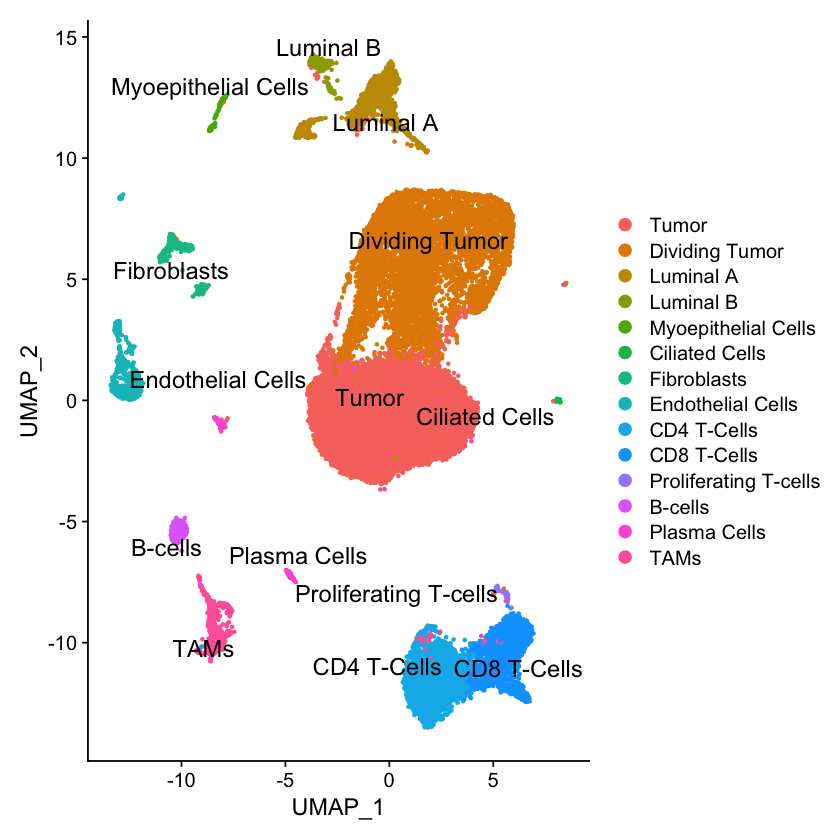

In [44]:
# Seurat Clusters
DimPlot(harmonized_seurat, 
              reduction = "UMAP",
              # group.by = "seurat_clusters",
              label = TRUE, pt.size = 0.5, 
              label.size = 5, repel = TRUE)

ggsave("scClusters.jpeg", plot = last_plot(),
       width = 12.5, height = 10,     
       dpi = 1800,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


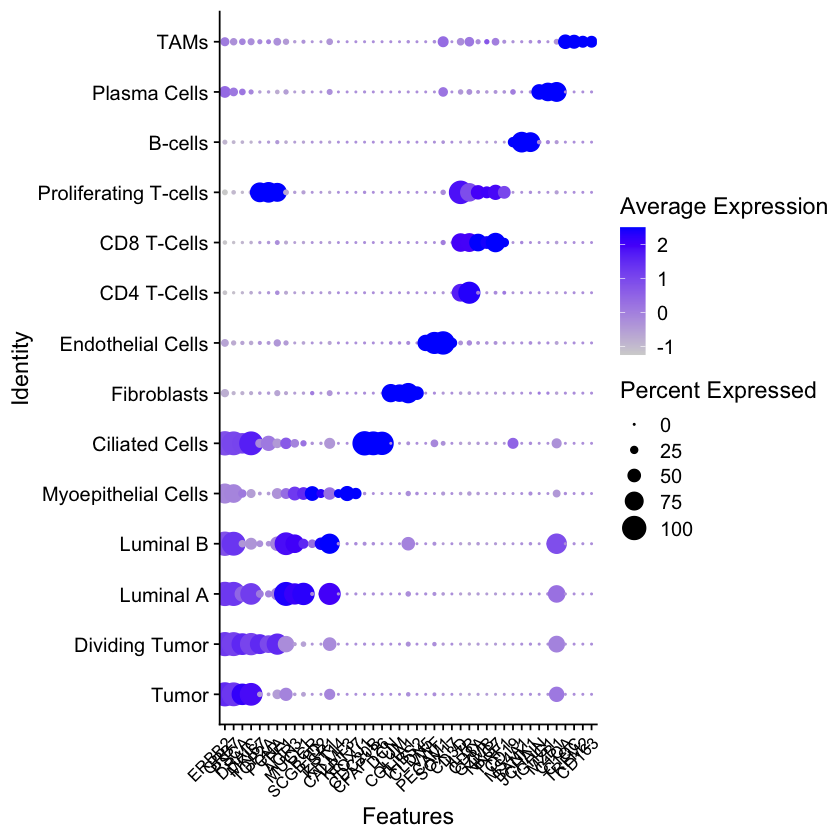

In [47]:
genes_to_plot <- c(
  # TUMOR: HER2+ Lineage
  "ERBB2", "GRB7", "PSCA", "DRAIC",      
  "MKI67", "TOP2A", "PCNA",                      

  # TUMOR: Luminal Lineage
  "TFF1", "AGR3", "MUCL1",             
  "PGR", "SCGB1D2", "ESR1",             

  # EPITHELIUM 
  "KRT14", "CALML3", "KRT17",           
  "FOXJ1", "CDC20B", "CFAP126",         

  # STROMA
  "DCN", "LUM", "COL1A1", "THBS2",      
  "CLDN5", "VWF", "PECAM1", "SOX17",     

  # IMMUNE: T-Cells
  "CD3D", "IL7R", 
  "CD8A", "GZMB", "NKG7", "PRF1",        
  
  # IMMUNE: B-Cells & Plasma
  "CD19", "MS4A1", "BANK1",             
  "JCHAIN", "IGHG1", "MZB1",            

  # IMMUNE: Myeloid
  "C1QA", "C1QC", "TREM2", "CD163"       
)

# Remove any genes not found
genes_to_plot <- genes_to_plot[genes_to_plot %in% rownames(harmonized_seurat)]

DotPlot(
  harmonized_seurat,
  features = genes_to_plot,
  # group.by = "CellType", 
) + 
  RotatedAxis() +                
  theme(axis.text.x = element_text(size = 10)) 

ggsave("scDotPlot.jpeg", plot = last_plot(),
       width = 16, height = 6,     
       dpi = 1800,                
       type = "cairo")

In [49]:
harmonized_seurat@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,Capture,RNA_snn_res.0.22,seurat_clusters,cell_type_ordered,CellType
,<chr>,<dbl>,<int>,<dbl>,<chr>,<fct>,<fct>,<fct>,<fct>
Capture_3'_AAACCCACACAACGAG-1,SeuratProject,16951,4423,28.1694295,3',0,0,HER2+ Tumor,Tumor
Capture_3'_AAACCCAGTGGAACCA-1,SeuratProject,4490,1793,6.0356347,3',2,2,CD4+ T-Cells,CD4 T-Cells
Capture_3'_AAACGAACAAGCCTGC-1,SeuratProject,2932,1428,8.4242838,3',8,8,iCAF,Fibroblasts
Capture_3'_AAACGCTCATATAGCC-1,SeuratProject,19092,5242,11.8426566,3',0,0,HER2+ Tumor,Tumor
Capture_3'_AAACGCTGTGGCTTGC-1,SeuratProject,31555,6172,19.8193630,3',1,1,Cycling Cells,Dividing Tumor
Capture_3'_AAACGCTGTTAGGCTT-1,SeuratProject,1351,783,14.2116950,3',2,2,CD4+ T-Cells,CD4 T-Cells
Capture_3'_AAAGAACCAGGCCTGT-1,SeuratProject,24622,5726,14.0809033,3',7,7,TAMs,TAMs
Capture_3'_AAAGAACTCAGGGATG-1,SeuratProject,15124,3674,5.5937583,3',7,7,TAMs,TAMs
Capture_3'_AAAGGATGTCCGTTTC-1,SeuratProject,34369,6852,12.7964154,3',1,1,Cycling Cells,Dividing Tumor


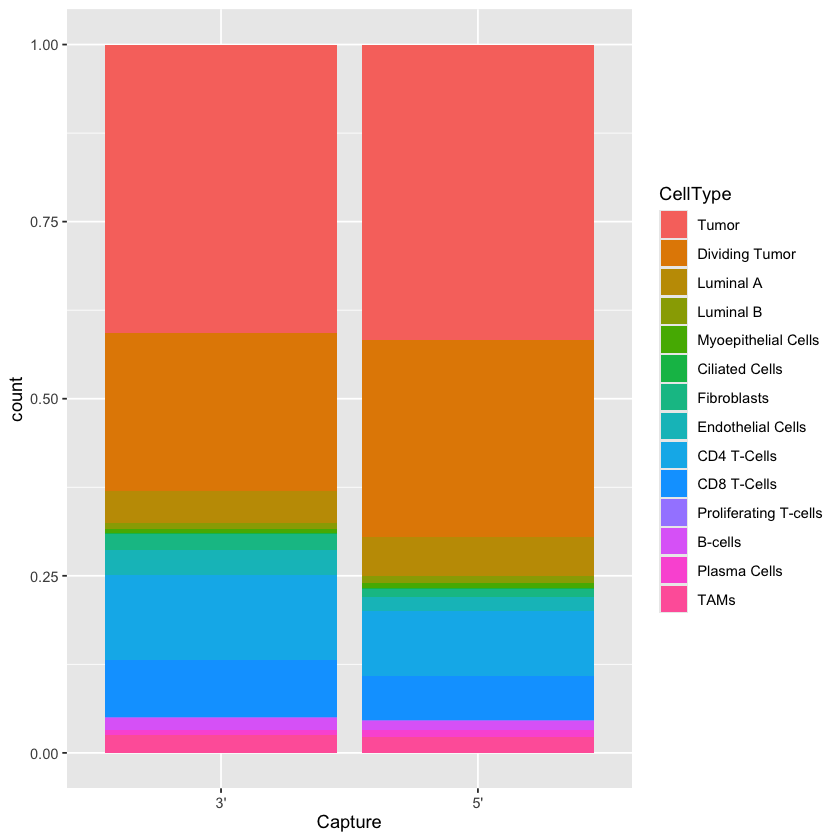

In [54]:
# Stacked Bar Plot

ggplot(harmonized_seurat@meta.data, aes(x=Capture, fill=CellType)) + geom_bar(position = "fill")

ggsave( 
  "Cluster per Capture Method.jpeg",
  plot   = last_plot(),
  width  = 11,
  height = 30,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [46]:
saveRDS(harmonized_seurat, file = "./Visium/Seurat_Clusters.rds")